# Importing Libraries

In [1]:
import os
import pandas as pd
import pickle
import shutil
import numpy as np
import seaborn as sns
from sklearn.datasets import load_files
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from PIL import ImageFile
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tqdm import tqdm

from tensorflow.keras.applications.vgg16 import VGG16


# Defining the train,test and model directories

* We will create the directories for train,test and model training paths if not present

In [54]:
# Define the base path where your images are located
BASE_PATH = r"E:\Data\imgs"

# Define the directories
TEST_DIR = os.path.join(BASE_PATH, "test")
TRAIN_DIR = os.path.join(BASE_PATH, "train")
MODEL_PATH = os.path.join(os.getcwd(), "model", "vgg16")
PICKLE_PATH = os.path.join(os.getcwd(), "pickle")

# Define the CSV file paths
TEST_CSV = r"E:\Data\imgs\test_data.csv"
TRAIN_CSV = r"E:\Data\imgs\train_data.csv"


In [55]:
if not os.path.exists(TEST_DIR):
    print("Testing data does not exists")
if not os.path.exists(TRAIN_DIR):
    print("Training data does not exists")
if not os.path.exists(MODEL_PATH):
    print("Model path does not exists")
    os.makedirs(MODEL_PATH)
    print("Model path created")
else:
    shutil.rmtree(MODEL_PATH)
    os.makedirs(MODEL_PATH)
if not os.path.exists(PICKLE_PATH):
    os.makedirs(PICKLE_PATH)

In [56]:
data_train = pd.read_csv(TRAIN_CSV)
data_test = pd.read_csv(TEST_CSV)

In [57]:
# Get unique labels from the 'classname' column
labels_list = list(set(data_train['classname'].values.tolist()))
labels_id = {label_name: id for id, label_name in enumerate(labels_list)}
print(labels_id)

# Replace classname values with their corresponding IDs
data_train['classname'].replace(labels_id, inplace=True)

# Convert labels to categorical format
labels = to_categorical(data_train['classname'])
print(labels.shape)

# Save the labels dictionary to a pickle file
with open(os.path.join(PICKLE_PATH, "labels_list_vgg16.pkl"), "wb") as handle:
    pickle.dump(labels_id, handle)


{'c8': 0, 'c6': 1, 'c3': 2, 'c4': 3, 'c5': 4, 'c7': 5, 'c2': 6, 'c1': 7, 'c9': 8, 'c0': 9}
(22424, 10)


C:\Users\tharu\AppData\Local\Temp\ipykernel_1960\1020366040.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['classname'].replace(labels_id, inplace=True)
C:\Users\tharu\AppData\Local\Temp\ipykernel_1960\1020366040.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_train['classna

# Data Preparation

1. Converting the all the train and test images into image size of 64,64,3 
2. Standardizing the flattened image vector 

In [58]:
# Prepare labels and split the data
labels = data_train['classname'].values  # Get labels from the 'classname' column
xtrain, xtest, ytrain, ytest = train_test_split(data_train['img'], labels, test_size=0.2, random_state=42)

ImageFile.LOAD_TRUNCATED_IMAGES = True

def path_to_tensor(img_path):
    img = tf_image.load_img(img_path, target_size=(64, 64))
    x = tf_image.img_to_array(img)
    return np.expand_dims(x, axis=0)

def paths_to_tensor(img_paths):
    list_of_tensors = [path_to_tensor(img_path) for img_path in tqdm(img_paths)]
    return np.vstack(list_of_tensors)


In [59]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
from keras.preprocessing import image as keras_image

def path_to_tensor(img_path):
    if not os.path.exists(img_path):
        print(f"File not found: {img_path}")  # Debugging line
        return None  # Handle missing file case
    img = Image.open(img_path)
    img = img.resize((64, 64))  # Resize the image to the target size
    x = keras_image.img_to_array(img)  # Convert the image to a numpy array
    return np.expand_dims(x, axis=0)  # Add a new dimension

def paths_to_tensor(img_paths):
    list_of_tensors = [path_to_tensor(img_path) for img_path in tqdm(img_paths)]
    # Remove None values
    list_of_tensors = [tensor for tensor in list_of_tensors if tensor is not None]
    
    if len(list_of_tensors) == 0:  # Check if the list is empty
        print("No valid images found to process.")
        return None  # Avoid concatenating an empty list
    
    return np.vstack(list_of_tensors)

# Assuming your images are stored in a directory like this:
image_directory = "E:\\Data\\imgs"  # Update with your actual directory path

# Modify xtrain and xtest to include the full image path
xtrain_full_paths = [os.path.join(image_directory, "train", img) for img in xtrain]
xtest_full_paths = [os.path.join(image_directory, "test", img) for img in xtest]

# Debugging line to check paths
print("Training Image Paths:", xtrain_full_paths)

# Pre-process the data for Keras
train_tensors = paths_to_tensor(xtrain_full_paths)
if train_tensors is not None:
    train_tensors = train_tensors.astype('float32') / 255 - 0.5

valid_tensors = paths_to_tensor(xtest_full_paths)
if valid_tensors is not None:
    valid_tensors = valid_tensors.astype('float32') / 255 - 0.5


Training Image Paths: ['E:\\Data\\imgs\\train\\c6\\img_34180.jpg', 'E:\\Data\\imgs\\train\\c4\\img_97609.jpg', 'E:\\Data\\imgs\\train\\c1\\img_8943.jpg', 'E:\\Data\\imgs\\train\\c1\\img_15989.jpg', 'E:\\Data\\imgs\\train\\c7\\img_89930.jpg', 'E:\\Data\\imgs\\train\\c9\\img_64368.jpg', 'E:\\Data\\imgs\\train\\c0\\img_36808.jpg', 'E:\\Data\\imgs\\train\\c6\\img_102074.jpg', 'E:\\Data\\imgs\\train\\c0\\img_52244.jpg', 'E:\\Data\\imgs\\train\\c9\\img_92450.jpg', 'E:\\Data\\imgs\\train\\c0\\img_12247.jpg', 'E:\\Data\\imgs\\train\\c2\\img_34451.jpg', 'E:\\Data\\imgs\\train\\c8\\img_52284.jpg', 'E:\\Data\\imgs\\train\\c5\\img_24547.jpg', 'E:\\Data\\imgs\\train\\c3\\img_74807.jpg', 'E:\\Data\\imgs\\train\\c4\\img_96595.jpg', 'E:\\Data\\imgs\\train\\c4\\img_61077.jpg', 'E:\\Data\\imgs\\train\\c3\\img_30062.jpg', 'E:\\Data\\imgs\\train\\c1\\img_59890.jpg', 'E:\\Data\\imgs\\train\\c9\\img_64627.jpg', 'E:\\Data\\imgs\\train\\c4\\img_13973.jpg', 'E:\\Data\\imgs\\train\\c2\\img_35305.jpg', 'E:\\Data

100%|██████████| 4485/4485 [00:49<00:00, 90.33it/s] 


# MODEL ARCHITECTURE

## Approach Used
1. Removing the top layer of VGG16 model
2. Using the n-1 layers of VGG16 to predict the last layer of it using the flattened image vector 
3. The last layer thus achieved is a dense feature representation for a particular image
4. Passing this layer feature through a GlobalAveragePooling Layer and a further dense softmax layer for each of 10 classes

## Benefits

1. Making CNN architecture from scratch involves in training of all the deep layers which results in slow training
2. Instead of a large sparse image vector a dense feature representation used here requires less memory while training

In [60]:
model = VGG16(include_top=False)
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [61]:
train_vgg16 = model.predict(train_tensors,verbose=1)
valid_vgg16 = model.predict(valid_tensors,verbose=1)

141/141 [==============================] - 54s 384ms/step


In [62]:
print("Train shape",train_vgg16.shape)
print("Validation shape",valid_vgg16.shape)

Train shape (17939, 2, 2, 512)
Validation shape (4485, 2, 2, 512)


In [ ]:
train_features = train_vgg16[0]
valid_features = valid_vgg16[0] 

In [64]:
print("Train features shape",train_features.shape)
print("Validation features shape",valid_features.shape)

Train features shape (2, 2, 512)
Validation features shape (2, 2, 512)


In [65]:
VGG16_model = Sequential()
VGG16_model.add(GlobalAveragePooling2D(input_shape=train_features.shape))
VGG16_model.add(Dense(10, activation='softmax', kernel_initializer='glorot_normal'))

VGG16_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 global_average_pooling2d_1  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 10)                5130      
                                                                 
Total params: 5130 (20.04 KB)
Trainable params: 5130 (20.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [66]:
VGG16_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [67]:
plot_model(VGG16_model,to_file=os.path.join(os.getcwd(),"model","vgg16","model_distracted_driver_vgg16.png"),show_shapes=True,show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [68]:
filepath = os.path.join(MODEL_PATH,"distracted-{epoch:02d}-{val_accuracy:.2f}.hdf5")
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max',period=1)
callbacks_list = [checkpoint]

In [69]:
from keras.utils import to_categorical

# Assuming ytrain and ytest are the class indices
num_classes = 10  # Adjust if necessary
ytrain = to_categorical(ytrain, num_classes)
ytest = to_categorical(ytest, num_classes)


In [70]:
print("ytrain shape:", ytrain.shape)  # Should be (num_samples, 10)
print("ytest shape:", ytest.shape)  # Should be (num_samples, 10)


ytrain shape: (17939, 10)
ytest shape: (4485, 10)


In [71]:
from keras.models import Sequential
from keras.layers import Dense, Flatten  # etc.

VGG16_model = Sequential()
# ... Add your VGG16 base and any additional layers here ...
VGG16_model.add(Flatten())
VGG16_model.add(Dense(num_classes, activation='softmax'))  # Adjust to match the number of classes


In [72]:
VGG16_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [73]:
model_history = VGG16_model.fit(train_vgg16, ytrain, 
                                 validation_data=(valid_vgg16, ytest), 
                                 epochs=400, 
                                 batch_size=16, 
                                 shuffle=True, 
                                 callbacks=callbacks_list)


Epoch 1/400
1105/1122 [============================>.] - ETA: 0s - loss: 0.9676 - accuracy: 0.7396
Epoch 1: val_accuracy improved from -inf to 0.89365, saving model to e:\Distracted-Driver-Detection-Using-Deep-Learning-main\Training Notebooks\model\vgg16\distracted-01-0.89.hdf5
1122/1122 [==============================] - 3s 2ms/step - loss: 0.9608 - accuracy: 0.7418 - val_loss: 0.5061 - val_accuracy: 0.8936
Epoch 2/400
  84/1122 [=>............................] - ETA: 1s - loss: 0.4848 - accuracy: 0.9033

c:\Users\tharu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1075/1122 [===========================>..] - ETA: 0s - loss: 0.4035 - accuracy: 0.9131
Epoch 2: val_accuracy improved from 0.89365 to 0.92575, saving model to e:\Distracted-Driver-Detection-Using-Deep-Learning-main\Training Notebooks\model\vgg16\distracted-02-0.93.hdf5
1122/1122 [==============================] - 2s 1ms/step - loss: 0.4013 - accuracy: 0.9134 - val_loss: 0.3324 - val_accuracy: 0.9258
Epoch 3/400
1112/1122 [============================>.] - ETA: 0s - loss: 0.2659 - accuracy: 0.9460
Epoch 3: val_accuracy improved from 0.92575 to 0.95407, saving model to e:\Distracted-Driver-Detection-Using-Deep-Learning-main\Training Notebooks\model\vgg16\distracted-03-0.95.hdf5
1122/1122 [==============================] - 2s 1ms/step - loss: 0.2657 - accuracy: 0.9460 - val_loss: 0.2316 - val_accuracy: 0.9541
Epoch 4/400
1102/1122 [============================>.] - ETA: 0s - loss: 0.2009 - accuracy: 0.9585
Epoch 4: val_accuracy did not improve from 0.95407
1122/1122 [=====================

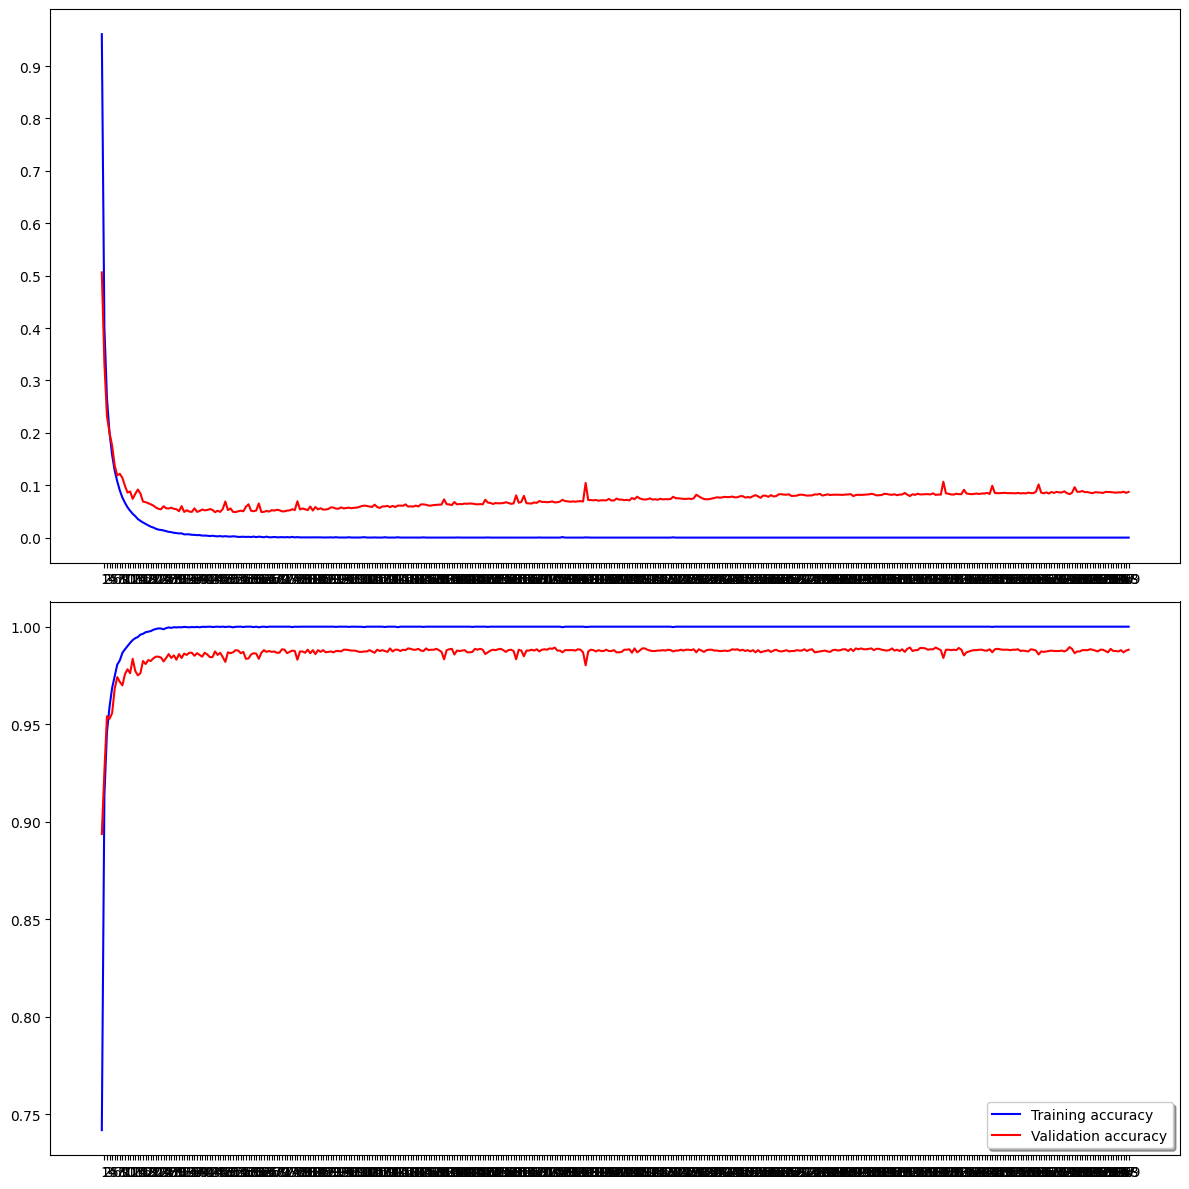

In [74]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(model_history.history['loss'], color='b', label="Training loss")
ax1.plot(model_history.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, 400, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))

ax2.plot(model_history.history['accuracy'], color='b', label="Training accuracy")
ax2.plot(model_history.history['val_accuracy'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(1, 400, 1))

legend = plt.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

# Model Analysis
Finding the Confusion matrix,Precision,Recall and F1 score to analyse the model thus created

In [75]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=14):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names, 
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig.savefig(os.path.join(MODEL_PATH,"confusion_matrix.png"))
    return fig

In [76]:
def print_heatmap(n_labels, n_predictions, class_names):
    labels = n_labels #sess.run(tf.argmax(n_labels, 1))
    predictions = n_predictions #sess.run(tf.argmax(n_predictions, 1))

#     confusion_matrix = sess.run(tf.contrib.metrics.confusion_matrix(labels, predictions))
    matrix = confusion_matrix(labels.argmax(axis=1),predictions.argmax(axis=1))
    row_sum = np.sum(matrix, axis = 1)
    w, h = matrix.shape

    c_m = np.zeros((w, h))

    for i in range(h):
        c_m[i] = matrix[i] * 100 / row_sum[i]

    c = c_m.astype(dtype = np.uint8)

    
    heatmap = print_confusion_matrix(c, class_names, figsize=(18,10), fontsize=20)

In [77]:
class_names = list()
for name,idx in labels_id.items():
    class_names.append(name)
# print(class_names)
ypred = VGG16_model.predict(valid_vgg16,verbose=1)

141/141 [==============================] - 0s 1ms/step


## Confusion Matrix

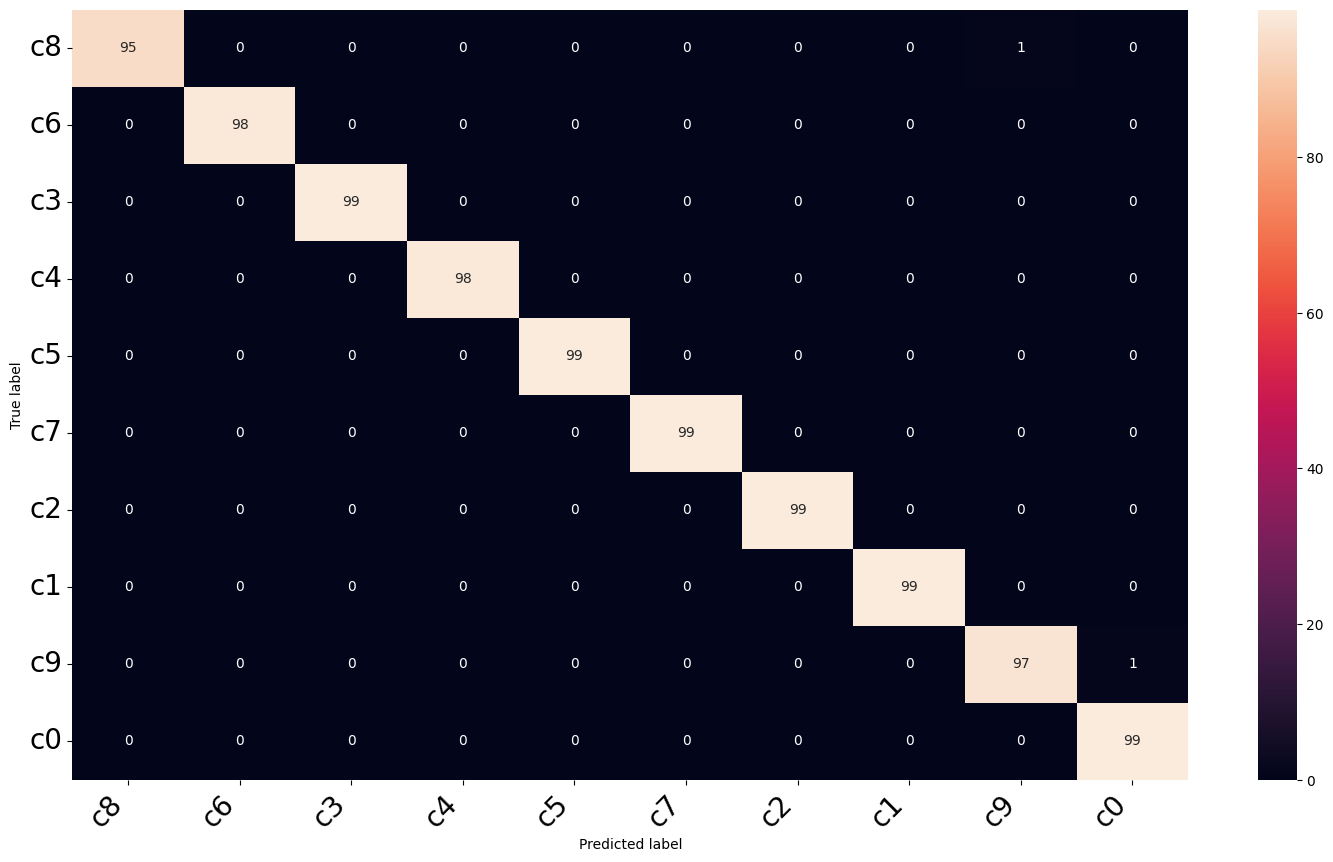

In [78]:
print_heatmap(ytest,ypred,class_names)

# Precision Recall F1 Score

In [79]:
ypred_class = np.argmax(ypred,axis=1)
# print(ypred_class[:10])
ytest = np.argmax(ytest,axis=1)

In [80]:
accuracy = accuracy_score(ytest,ypred_class)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(ytest, ypred_class,average='weighted')
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(ytest,ypred_class,average='weighted')
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(ytest,ypred_class,average='weighted')
print('F1 score: %f' % f1)

Accuracy: 0.988183
Precision: 0.988199
Recall: 0.988183
F1 score: 0.988162
